In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import multiprocessing

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import TensorDataset, DataLoader, random_split
from PIL import Image


In [2]:
import kagglehub

path = kagglehub.dataset_download("arunrk7/surface-crack-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'surface-crack-detection' dataset.
Path to dataset files: /kaggle/input/surface-crack-detection


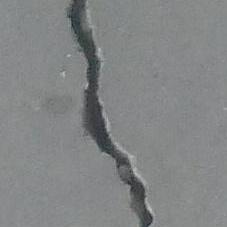

In [3]:
Image.open(r'/kaggle/input/surface-crack-detection/Positive/00001.jpg')

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [5]:
def transfornation(train:bool):
    if train:
        return transforms.Compose([
            transforms.Resize(124),
            transforms.RandomCrop(110),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5),(0.5, 0.5, 0.5))
        ])
    else:
        return transforms.Compose([
            transforms.Resize(124),
            transforms.CenterCrop(110),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5),(0.5, 0.5, 0.5))
        ])


In [6]:
class transformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        return self.transform(image), label

    def __len__(self):
        return len(self.subset)


In [7]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_lyr = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Dropout2d(0.2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Dropout2d(0.3),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Dropout2d(0.4),
        )
        self.linear = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        x = self.conv_lyr(x)
        x = self.linear(x)
        return x

In [8]:
dataset = datasets.ImageFolder(r'/kaggle/input/surface-crack-detection')

In [9]:
train = int(len(dataset) * 0.8)
val = int(len(dataset) - train)

In [10]:
dataset.class_to_idx

{'Negative': 0, 'Positive': 1}

In [11]:
train_set, val_set = random_split(dataset, [train, val])

In [12]:
train_set = transformSubset(train_set, transform=transfornation(True))
val_set = transformSubset(val_set, transfornation(False))

In [13]:
train_loader = DataLoader(train_set, shuffle=True, batch_size=64, num_workers=8)
val_loader = DataLoader(val_set, shuffle=False, batch_size=64, num_workers=8)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [14]:
model = CNN().to(device)
optimizer = optim.Adam(model.parameters())
critrion = nn.BCELoss()


In [15]:
epochs = 5

best_acc = 0
for epoch in range(epochs):
    total = 0
    correct = 0
    running_loss = 0.0

    model.train()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        output = model(images).squeeze(1)
        loss = critrion(output, labels.float())
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    batch_loss = running_loss / len(train_loader)

    model.eval()
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            output = model(images)
            pred = (output > 0.5).squeeze(1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()

    val_acc = correct/total * 100
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_paramiters.pt')

    print(f'For Epoch {epoch+1}, training loss = {batch_loss:.4f}, validation_acc = {val_acc:.4f}')


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


For Epoch 1, training loss = 0.0610, validation_acc = 99.5375
For Epoch 2, training loss = 0.0345, validation_acc = 99.6875
For Epoch 3, training loss = 0.0234, validation_acc = 99.7375
For Epoch 4, training loss = 0.0211, validation_acc = 99.7875
For Epoch 5, training loss = 0.0195, validation_acc = 99.8250


In [18]:
model.load_state_dict(torch.load('best_paramiters.pt'))

<All keys matched successfully>

## Check Individually


In [41]:
def check_for_crack(img):
  path_c = path + '/' + img
  image = Image.open(path_c)
  img_tensor = transfornation(False)(image).unsqueeze(0).to(device)

  model.eval()
  with torch.no_grad():
    output = model(img_tensor).squeeze(1)
    pred_class = (output > 0.5).int().item()
  prediction_map = {0: 'Negative', 1: 'Positive'}
  plt.imshow(image)
  plt.show()
  return prediction_map[pred_class]



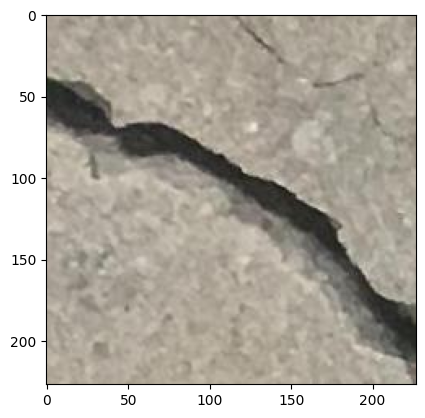

'Positive'

In [43]:
check_for_crack("Positive/00660.jpg")

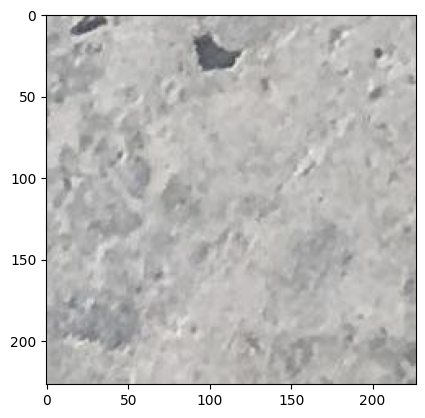

'Negative'

In [44]:
check_for_crack("Negative/00427.jpg")